In [1]:
### imports...
import numpy as np
import matplotlib.pyplot as plt

In [2]:
### basic work for paper tables wrt dataset size
layer_res = [30, 30, 30, 30, 30, 30, 30, 30, 800, 800, 800, 800, 800, 800, 1000, 70, 70, 1000]
pyr_x = np.array([34, 34, 34, 34, 34, 34, 34, 34, 2, 2, 2, 2, 2, 2, 1, 15, 15, 1])
cube_x = np.array([34, 34, 34, 34, 34, 34, 34, 34, 34, 34, 34, 34, 34, 34, 34, 15, 15, 1])
old_adj_x = np.array([24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 15, 15, 1])
adj_x = np.array([25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 15, 15, 1])
y_sum = np.sum(np.array([15, 15, 1]) ** 2)

In [3]:
params_pyr = np.sum(pyr_x ** 2)
params_cube = np.sum(cube_x ** 2)
params_adj = np.sum(adj_x ** 2)
params_old = np.sum(old_adj_x ** 2)

In [4]:
print(params_pyr)
print(params_cube)
print(params_adj)
print("***")
print(params_pyr - y_sum)
print(params_cube - y_sum)
print(params_adj - y_sum)
print("***")
print(1 - (params_pyr/params_cube))

9724
17791
9826
***
9273
17340
9375
***
0.4534315103142038


In [5]:
### overhead and storage cost graph
gb_pyr = 3.86
gb_cube = 7.06
gb_adj = (params_adj / params_old) * 3.61

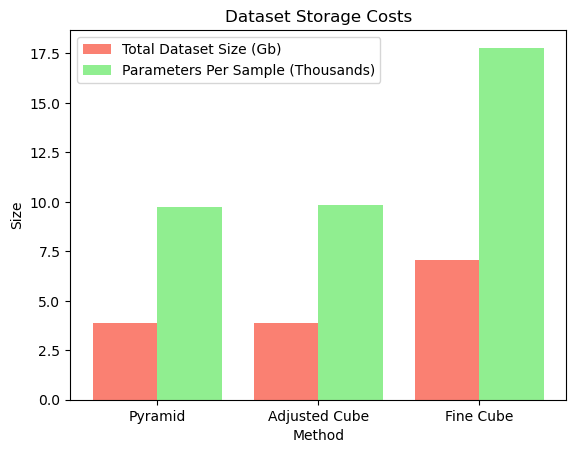

In [6]:
names = ["Pyramid", "Adjusted Cube", "Fine Cube"]
index = np.array([1, 2, 3])
fig, ax = plt.subplots()
disk = ax.bar(index-0.5, [gb_pyr, gb_adj, gb_cube], 0.4, color="salmon")
disk = ax.bar(index-0.1, [params_pyr/1000, params_adj/1000, params_cube/1000], 0.4, color="lightgreen")

ax.set_xticks(index-0.3, names)
ax.set_title("Dataset Storage Costs")
ax.legend(loc='upper left', labels=["Total Dataset Size (Gb)", "Parameters Per Sample (Thousands)"])
ax.set_ylabel('Size')
ax.set_xlabel('Method')

plt.savefig("data_cost_figs/storage_cost.png")

In [7]:
### work on graph for overhead time cost

In [11]:
### ok -- now compile results for model performance table...
import pickle

models_locs = [["../models/trained/c2_early_pyramid", "cascade_early_1"],
               ["../models/trained/c2_early_cube", "cascade_early_1"],
               ["../models/trained/c2_early_adjust", "cascade_early_1"],
               ["../models/trained/mid_pyramid_lab", "cascade_late_1"],
               ["../models/trained/mid_cube_lab", "cascade_late_1"],
               ["../models/trained/c2_mid_adjust", "cascade_mid_1"],
               ["../models/trained/late_pyramid_lab", "cascade_late_1"],
               ["../models/trained/late_cube_lab", "cascade_late_1"],
               ["../models/trained/c2_late_a_adjust", "cascade_late_1"],
               ["../models/trained/t1_pyramid_lab", "vit_pyramid_1"],
               ["../models/trained/t1_cube_lab", "vit_pyramid_1"],
               ["../models/trained/t1_adjust_lab", "vit_adjust_1"],
               ["../models/trained/f2_baseline_cube", "f2_baseline_1"],
               ["../models/trained/f2_baseline_adjust", "f2_baseline_1"]]




In [12]:
### load metrics pickles
models_metrics = []
for i in range(len(models_locs)):
    print(models_locs[i][0] + "/metrics.txt")
    with open(models_locs[i][0] + "/metrics.txt", "rb") as metrics_log:
        models_metrics.append(pickle.load(metrics_log))

../models/trained/c2_early_pyramid/metrics.txt
../models/trained/c2_early_cube/metrics.txt
../models/trained/c2_early_adjust/metrics.txt
../models/trained/mid_pyramid_lab/metrics.txt
../models/trained/mid_cube_lab/metrics.txt
../models/trained/c2_mid_adjust/metrics.txt
../models/trained/late_pyramid_lab/metrics.txt
../models/trained/late_cube_lab/metrics.txt
../models/trained/c2_late_a_adjust/metrics.txt
../models/trained/t1_pyramid_lab/metrics.txt
../models/trained/t1_cube_lab/metrics.txt
../models/trained/t1_adjust_lab/metrics.txt
../models/trained/f2_baseline_cube/metrics.txt
../models/trained/f2_baseline_adjust/metrics.txt


In [13]:
### organization: [metric_type, ylayer, fold]
y_layer_names = ["wue", "esi", "agb"]
print(models_metrics[0]["total_time"])
for i in range(len(models_metrics)):
    for j in range(3):
        print(models_locs[i][0], "--", y_layer_names[j] + "_mse", np.mean(models_metrics[i]["mse_single"][j][0]))
    print(models_locs[i][0], "--", y_layer_names[j] + "_time", models_metrics[i]["total_time"])
    print("**")

149.165179
../models/trained/c2_early_pyramid -- wue_mse 0.0011986719021938308
../models/trained/c2_early_pyramid -- esi_mse 0.014798512893760371
../models/trained/c2_early_pyramid -- agb_mse 0.008349828722173842
../models/trained/c2_early_pyramid -- agb_time 149.165179
**
../models/trained/c2_early_cube -- wue_mse 0.00476785650451972
../models/trained/c2_early_cube -- esi_mse 0.37524410190896984
../models/trained/c2_early_cube -- agb_mse 0.10616782639189548
../models/trained/c2_early_cube -- agb_time 174707.26524
**
../models/trained/c2_early_adjust -- wue_mse 0.00476785650451972
../models/trained/c2_early_adjust -- esi_mse 0.37524410190896984
../models/trained/c2_early_adjust -- agb_mse 0.1061678263918955
../models/trained/c2_early_adjust -- agb_time 98151.94693600001
**
../models/trained/mid_pyramid_lab -- wue_mse 0.0010648345680476243
../models/trained/mid_pyramid_lab -- esi_mse 0.015815402995645468
../models/trained/mid_pyramid_lab -- agb_mse 0.006931933557952623
../models/trained

In [24]:
### load data and do distribution graph ... imports
sys.path.append("..")
from models.data_handler import data_wrangler



In [49]:
### load wrangler
metadata_cols = []
with open("../data/ml_sets/pyramid_lf22/" + "info.txt", 'r') as infofile:
    metadata_total = infofile.read().replace('\n', ';')
metadata_lines = metadata_total.split(";")
metadata = []
for metal in metadata_lines:
    if len(metal) > 0:
        metadata.append(metal.split(","))

other_info = metadata.pop(0)
other_info = {"n_folds": other_info[0], "buffer_nodata": other_info[1], "base_crs": other_info[2],
                }
n_layers = len(metadata)
layer_info = {"layer_dims": [], "x_layers": [], "y_layers": [], "layer_names": []}

for j in range(n_layers):
    layer_info["layer_dims"].append(int(metadata[j][0]))
    layer_info["layer_names"].append(metadata[j][3])
    if metadata[j][1] == "x":
        layer_info["x_layers"].append(j)
    else:
        layer_info["y_layers"].append(j)

print("metadata check")

wrangler = data_wrangler("../data/ml_sets/pyramid_lf22/", 18, 1, layer_info["layer_dims"],
                                   1000, other_info["buffer_nodata"], layer_info["x_layers"],
                                   layer_info["y_layers"])

y_names = [["Water Use Efficiency", "wue"],
           ["Evaporative Stress Index", "esi"],
           ["Above Ground Biomass", "agb"]]
colors = ["salmon", "lightgreen", "lightblue"]
distkey = ["WUE", "ESI", "AGB"]

metadata check


/var/folders/kq/5tk5wpns4_lc_q8b14gl0m2h0000gn/T/ipykernel_57648/1052939765.py:23: RuntimeWarning: divide by zero encountered in log10
  ax.plot(np.arange(nbins), np.log10(ys[i]), color=colors[i], label=distkey[i])


'\n### dist over vali\nwrangler.set_mode("val")\nys = [[] for iii in range(3)]\nfor i in range(len(wrangler)):\n    ### val y at batch i\n    ys_i = wrangler[i][1]\n    for j in range(3):\n        for elty in ys_i[j]:\n            ys[j].append(elty)\n\nfor i in range(3):\n    ys[i] = np.array(ys[i])\n    print("val shape sanity check", i, "-", ys[i].shape)\n\n### dist over test\nwrangler.set_mode("test")\nys = [[] for iii in range(3)]\nfor i in range(len(wrangler)):\n    ### val y at batch i\n    ys_i = wrangler[i][1]\n    for j in range(3):\n        for elty in ys_i[j]:\n            ys[j].append(elty)\n\nfor i in range(3):\n    ys[i] = np.array(ys[i])\n    print("test shape sanity check", i, "-", ys[i].shape)'

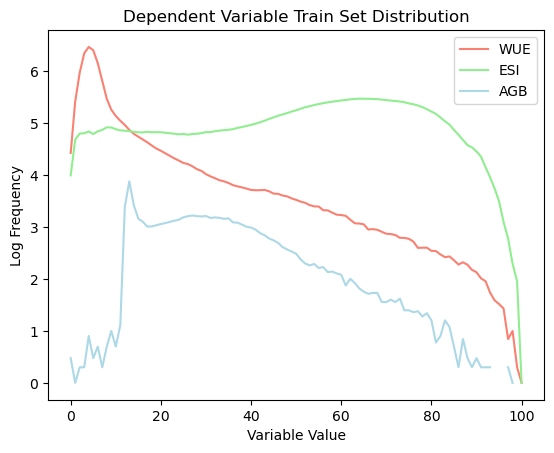

In [58]:
nbins = 200

### dist over train
wrangler.set_mode("train")
ys = [[] for iii in range(3)]

for i in range(len(wrangler)):
    ### val y at batch i
    ys_i = wrangler[i][1]
    for j in range(3):
        for elty in ys_i[j]:
            ys[j].append(elty)
"""
for i in range(3):
    ys[i] = np.arange(500 * (i + 1))/(250 * (i + 1)) """



fig, ax = plt.subplots()

for i in range(3):
    ys[i], b = np.histogram(ys[i], nbins, range=[0, 2])
    ax.plot(np.arange(nbins), np.log10(ys[i]), color=colors[i], label=distkey[i])
ax.set(xlabel='Variable Value', ylabel='Log Frequency', title='Dependent Variable Train Set Distribution')
ax.legend(loc="upper right")

"""
### dist over vali
wrangler.set_mode("val")
ys = [[] for iii in range(3)]
for i in range(len(wrangler)):
    ### val y at batch i
    ys_i = wrangler[i][1]
    for j in range(3):
        for elty in ys_i[j]:
            ys[j].append(elty)

for i in range(3):
    ys[i] = np.array(ys[i])
    print("val shape sanity check", i, "-", ys[i].shape)

### dist over test
wrangler.set_mode("test")
ys = [[] for iii in range(3)]
for i in range(len(wrangler)):
    ### val y at batch i
    ys_i = wrangler[i][1]
    for j in range(3):
        for elty in ys_i[j]:
            ys[j].append(elty)

for i in range(3):
    ys[i] = np.array(ys[i])
    print("test shape sanity check", i, "-", ys[i].shape)"""

In [ ]:
wrangler.set_mode("val")
ys = [[] for iii in range(3)]

for i in range(len(wrangler)):
    ### val y at batch i
    ys_i = wrangler[i][1]
    for j in range(3):
        for elty in ys_i[j]:
            ys[j].append(elty)
"""
for i in range(3):
    ys[i] = np.arange(500 * (i + 1))/(250 * (i + 1)) """



fig, ax = plt.subplots()

for i in range(3):
    ys[i], b = np.histogram(ys[i], nbins, range=[0, 2])
    ax.plot(np.arange(nbins), np.log10(ys[i]), color=colors[i], label=distkey[i])
ax.set(xlabel='Variable Value', ylabel='Log Frequency', title='Dependent Variable Train Set Distribution')
ax.legend(loc="upper right")